In [20]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv("merged_incidents.csv")
df["Incident Date"] = pd.to_datetime(df["Incident Date"], format="%Y/%m/%d")
df["Year"] = df["Incident Date"].dt.year
min_date = df["Incident Date"].min()
max_date = df["Incident Date"].max()

first_year = min_date.year
last_year = max_date.year

if min_date > pd.Timestamp(f"{first_year}-01-01"):
    df = df[df["Year"] != first_year]
if max_date < pd.Timestamp(f"{last_year}-12-31"):
    df = df[df["Year"] != last_year]

# Drop rows with missing key values
df = df.dropna(subset=["Incident Category", "Incident Date", "Longitude", "Latitude"])

Thorii

In [21]:
# Define personal focus crimes
personal_focus_crimes = ['human trafficking (a), commercial sex acts', 'human trafficking (b), involuntary servitude', 'missing person', 'kidnapping', ]

df['Police District'] = df['Police District'].str.upper()

# Get all unique police districts
districts = df['Police District'].unique()
districts = [d for d in districts if pd.notna(d)]

# Initialize dictionary to store results
crime_profiles = {}

# Compute P(crime) for each crime type (city-wide probability)
total_crimes = len(df)
p_crime = {}
for crime in personal_focus_crimes:
    p_crime[crime] = len(df[df['Incident Category'] == crime]) / total_crimes

# Compute P(crime|district) / P(crime) for each district and crime
for district in districts:
    district_df = df[df['Police District'] == district]
    total_district_crimes = len(district_df)
    
    crime_profiles[district] = {}
    
    for crime in personal_focus_crimes:
        crime_in_district = len(district_df[district_df['Incident Category'] == crime])
        p_crime_given_district = crime_in_district / total_district_crimes if total_district_crimes > 0 else 0
        ratio = p_crime_given_district / p_crime[crime] if p_crime[crime] > 0 else 0
        crime_profiles[district][crime] = ratio

# Convert to DataFrame
profiles_df = pd.DataFrame(crime_profiles).T
profiles_df = profiles_df[personal_focus_crimes]

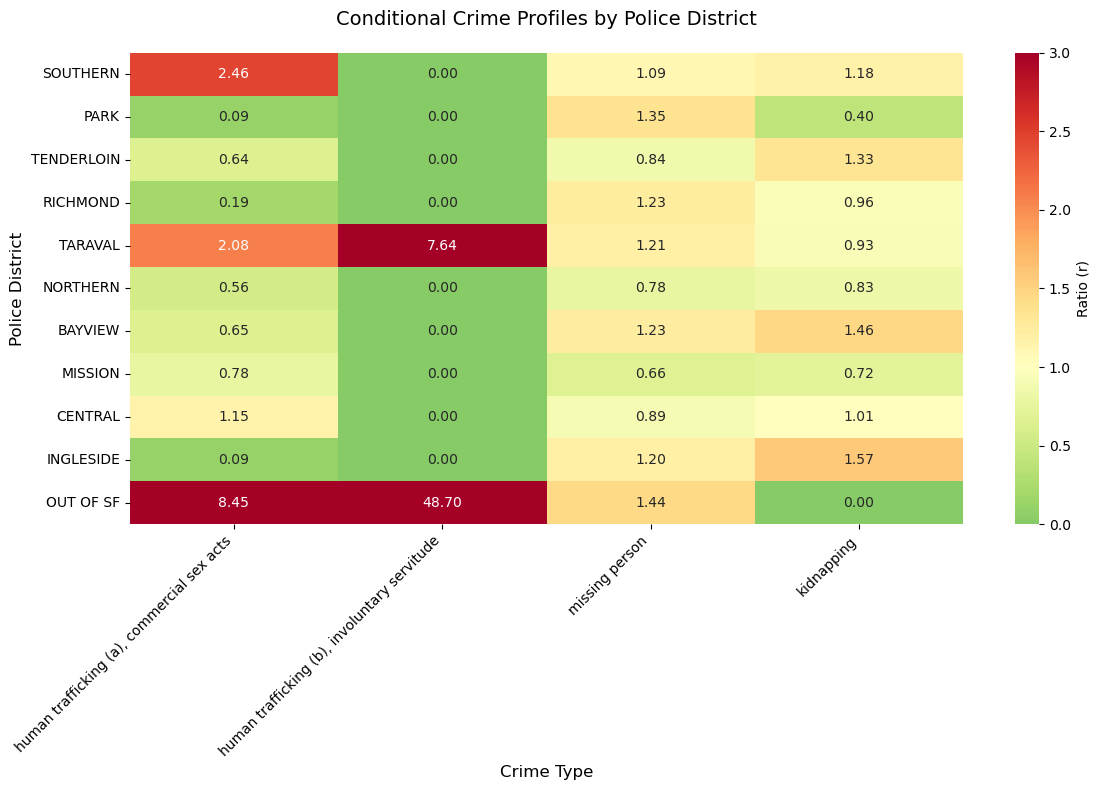

In [22]:
plt.figure(figsize=(12, 8))
sns.heatmap(profiles_df, annot=True, fmt='.2f', cmap='RdYlGn_r',
center=1, vmin=0, vmax=3, cbar_kws={'label': 'Ratio (r)'})
plt.title('Conditional Crime Profiles by Police District', fontsize=14, pad=20)
plt.xlabel('Crime Type', fontsize=12)
plt.ylabel('Police District', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('district_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

Julia

In [23]:
# lets see the count of all the crimes in the df
crime_counts = df["Incident Category"].value_counts()
crime_counts

Incident Category
missing person                                  66729
prostitution                                    17525
sex offenses, forcible                           8747
kidnapping                                       4282
human trafficking (a), commercial sex acts        121
sex offenses, non forcible                         43
human trafficking (b), involuntary servitude        3
Name: count, dtype: int64

In [24]:
# lets see the specific crime count for taraval for these focus crimes
taraval_df = df[df['Police District'] == 'TARAVAL']
taraval_crime_counts = taraval_df['Incident Category'].value_counts()
taraval_crime_counts

Incident Category
missing person                                  7020
sex offenses, forcible                           628
prostitution                                     475
kidnapping                                       348
human trafficking (a), commercial sex acts        22
sex offenses, non forcible                         3
human trafficking (b), involuntary servitude       2
Name: count, dtype: int64

So we cann see that for the "human trafficking (b), involuntary servitude" crime, there are 3 occurrences in the dataset, two of which are Taraval.

Text for the assignment:

The heatmap in Figure 1 tells a compelling story: a 7.64 location quotient suggests Taraval is a labor trafficking hotspot. But if we don't look at the raw numbers, this kind of heatmaps can be very missleading, especially when the underlying data is sparse.

What we are actually seeing is a statistical mirage known as the "Low-Count Ratio Effect". When the total number of events is incredibly low, even the smallest fluctuations create enormous ratios. Taraval shows a massive location quotient not because it's a crime epicenter, but because of how proportions react to exceptionally rare events. When the citywide total is almost zero, every single incident carries massive mathematical weight.

Human trafficking crimes are exceedingly rare in this dataset. There are exactly three reported incidents of involuntary servitude across the entire city over the last 20 years. Because that baseline is only three, the fact that two of those incidents happened in Taraval distorts the math, making the district look like an epidemic relative to the rest of the city.

This statistical trap has serious real-world consequences. As the textbook Dirty Data, Bad Predictions warns, algorithms trained on skewed ratios can cause active harm. A predictive policing system fed only the heatmap above might unjustly flag Taraval for intensive enforcement based on just two incidents over two decades.

To visualize the truth, we mapped the absolute counts of our focus crimes. The map below plots Missing Person reports in Taraval as faint gray dots to show the actual volume of incidents. The glowing red markers represent those two isolated Human Trafficking reports.

While the Location Quotient ratio (Figure 1) flagged Taraval as a labor trafficking hotspot, this Folium scatter map reveals the harsh reality. Over 20 years, only 2 actual labor trafficking incidents (red dots) were reported in Taraval. By contrast, the 7,020 missing person incidents (gray dots—the most common crime type in Taraval) demonstrate that the district's actual crime profile is driven by everyday missing persons cases, not by trafficking epidemics.

Figure 2: Absolute count of labor trafficking (red dots) versus missing persons (gray dots) in Taraval.

In [25]:
# Extract labor trafficking incidents in Taraval
labor_trafficking_taraval = df[
    (df['Police District'] == 'TARAVAL') & 
    (df['Incident Category'] == 'human trafficking (b), involuntary servitude')
]

# Get coordinates
labor_coords = labor_trafficking_taraval[['Latitude', 'Longitude']].values.tolist()


In [26]:
# Find most common crimes in Taraval for visual contrast
taraval_all = df[df['Police District'] == 'TARAVAL']
most_common_crimes = taraval_all['Incident Category'].value_counts().head(10)


# Select larceny/theft as the contrast crime (should be very high)
larceny_theft_taraval = taraval_all[
    (taraval_all['Incident Category'].str.contains('larceny|theft', case=False, na=False)) |
    (taraval_all['Incident Category'].str.contains('vehicle break', case=False, na=False)) |
    (taraval_all['Incident Category'] == 'larceny/theft')
]


# If larceny is low, use the most common crime instead
if len(larceny_theft_taraval) < 50:
    top_crime = most_common_crimes.index[0]
    contrast_crimes = taraval_all[taraval_all['Incident Category'] == top_crime]
else:
    contrast_crimes = larceny_theft_taraval

# Drop rows with missing coordinates
contrast_crimes_clean = contrast_crimes.dropna(subset=['Latitude', 'Longitude'])


In [27]:
import folium

# Taraval center coordinates
taraval_lat = 37.74
taraval_lon = -122.47

# Create base map centered on Taraval
m = folium.Map(
    location=[taraval_lat, taraval_lon],
    zoom_start=13,
    tiles='CartoDB positron'
)

# Add contrast crime dots (gray, semi-transparent, small)
# Following Week 5 Exercise 2.1 style
for idx, row in contrast_crimes_clean.iterrows():
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=2,
        popup=f"{row['Incident Category']}<br>{row['Incident Date']}",
        color='gray',
        fill=True,
        fillColor='gray',
        fillOpacity=0.25,
        weight=0.5
    ).add_to(m)

# Add labor trafficking incidents as prominent red markers
# These are the key data points we want to highlight
for idx, row in labor_trafficking_taraval.iterrows():
    year = pd.to_datetime(row['Incident Date']).year
    folium.CircleMarker(
        location=[row['Latitude'], row['Longitude']],
        radius=12,
        popup=f"<b>Human Trafficking (Involuntary Servitude)</b><br>Year: {year}<br>{row['Incident Description']}",
        color='red',
        fill=True,
        fillColor='darkred',
        fillOpacity=0.9,
        weight=2,
        tooltip=f"Labor Trafficking Incident - {year}"
    ).add_to(m)

# Save it for GitHub Pages integration
m.save('taraval_reality_map.html')

# Display the map in the notebook
from IPython.display import display
display(m)


ModuleNotFoundError: No module named 'folium'

## Figure 3: Interactive Crime Explorer
Explore any crime in the dataset. See the Location Quotient (statistical ratio) vs. Absolute Counts to investigate which hotspots are real and which are statistical illusions.


In [ ]:
import plotly.graph_objects as go
from ipywidgets import Dropdown, ToggleButtons, HBox, HTML, Output
from IPython.display import display, clear_output

# Compute LQ and absolute counts for ALL crimes
all_crimes = df['Incident Category'].unique()
all_crimes = sorted([c for c in all_crimes if pd.notna(c)])

# Store results for all crimes
all_crime_profiles = {}  # Location Quotient data
all_crime_counts = {}     # Absolute counts data

# Compute P(crime) for each crime type (city-wide probability)
total_crimes = len(df)
all_p_crime = {}
for crime in all_crimes:
    all_p_crime[crime] = len(df[df['Incident Category'] == crime]) / total_crimes

# Compute LQ and absolute counts for each district and crime
for crime in all_crimes:
    all_crime_profiles[crime] = {}
    all_crime_counts[crime] = {}
    
    for district in districts:
        district_df_temp = df[df['Police District'] == district]
        total_district_crimes = len(district_df_temp)
        
        crime_in_district = len(district_df_temp[district_df_temp['Incident Category'] == crime])
        
        # Store absolute count
        all_crime_counts[crime][district] = crime_in_district
        
        # Compute Location Quotient
        p_crime_given_district = crime_in_district / total_district_crimes if total_district_crimes > 0 else 0
        ratio = p_crime_given_district / all_p_crime[crime] if all_p_crime[crime] > 0 else 0
        all_crime_profiles[crime][district] = ratio

# Create the interactive function
def create_crime_visualization(crime, show_lq=True):
    """Create interactive bar chart for crime by district"""
    
    if crime not in all_crimes:
        return go.Figure().add_annotation(text="Crime not found in dataset")
    
    districts_list = list(districts)
    
    if show_lq:
        # Location Quotient view
        values = [all_crime_profiles[crime].get(d, 0) for d in districts_list]
        y_title = "Location Quotient Ratio"
        title_suffix = "(Statistical Distribution)"
        color_scale = "RdYlGn_r"  # Red-Yellow-Green reversed
        
        fig = go.Figure(data=[
            go.Bar(
                x=districts_list,
                y=values,
                marker=dict(
                    color=values,
                    colorscale=color_scale,
                    showscale=True,
                    line=dict(color='rgba(0,0,0,0.1)', width=0.5),
                    colorbar=dict(
                        title="LQ Ratio",
                        tickvals=[0, 1, 2, 3],
                        ticktext=["0", "1", "2", "3+"],
                        thickness=15,
                        len=0.7
                    )
                ),
                hovertemplate='<b>%{x}</b><br>LQ Ratio: %{y:.2f}<extra></extra>',
                text=[f'{v:.2f}' for v in values],
                textposition='outside',
                textfont=dict(size=10)
            )
        ])
        fig.add_hline(y=1, line_dash="dash", line_color="rgba(100,100,100,0.5)", 
                     line_width=2, annotation_text="City Baseline (1.0)",
                     annotation_position="right")
        
    else:
        # Absolute count view
        values = [all_crime_counts[crime].get(d, 0) for d in districts_list]
        y_title = "Number of Incidents"
        title_suffix = "(Actual Incident Counts)"
        
        # Color bars based on intensity
        colors = ['rgba(41, 128, 185, 0.8)' if v < max(values)/3 else 
                 'rgba(52, 152, 219, 0.8)' if v < 2*max(values)/3 else
                 'rgba(155, 89, 182, 0.8)' for v in values]
        
        fig = go.Figure(data=[
            go.Bar(
                x=districts_list,
                y=values,
                marker=dict(
                    color=colors,
                    line=dict(color='rgba(0,0,0,0.1)', width=0.5)
                ),
                hovertemplate='<b>%{x}</b><br>Incidents: %{y:,}<extra></extra>',
                text=[f'{int(v):,}' for v in values],
                textposition='outside',
                textfont=dict(size=10)
            )
        ])
    
    fig.update_layout(
        title=dict(
            text=f"<b style='font-size:18px'>{crime}</b><br><sub style='font-size:12px; color: #666'>{title_suffix}</sub>",
            x=0.5,
            xanchor='center',
            font=dict(size=16)
        ),
        xaxis_title="Police District",
        yaxis_title=y_title,
        hovermode="x unified",
        height=550,
        template="plotly_white",
        xaxis_tickangle=-45,
        margin=dict(b=120, l=80, r=80, t=100),
        font=dict(family="Arial, sans-serif", size=11, color="#333"),
        paper_bgcolor='rgba(249, 249, 249, 1)',
        plot_bgcolor='rgba(255, 255, 255, 1)',
        xaxis=dict(
            showgrid=True,
            gridwidth=1,
            gridcolor='rgba(200, 200, 200, 0.2)',
            showline=True,
            linewidth=1,
            linecolor='#ccc'
        ),
        yaxis=dict(
            showgrid=True,
            gridwidth=1,
            gridcolor='rgba(200, 200, 200, 0.2)',
            showline=True,
            linewidth=1,
            linecolor='#ccc'
        )
    )
    
    return fig

# Create widgets for interaction with better styling
crime_dropdown = Dropdown(
    options=all_crimes,
    value=all_crimes[0],
    description='Crime Type:',
    disabled=False,
    style={'description_width': '120px', 'text_color': '#333'},
    layout={'width': '650px', 'padding': '8px'}
)

view_toggle = ToggleButtons(
    options=[('📊 Location Quotient', True), ('📈 Absolute Counts', False)],
    value=True,
    description='View:',
    style={'description_width': '60px', 'text_color': '#333'},
    button_style='',
    layout={'width': 'auto', 'padding': '8px'}
)

# Create output widget for displaying the figure
output_widget = Output()

def on_crime_or_view_change(change=None):
    """Update chart when crime or view mode changes"""
    with output_widget:
        clear_output(wait=True)
        fig = create_crime_visualization(crime_dropdown.value, view_toggle.value)
        display(fig)

# Bundle controls
crime_dropdown.observe(on_crime_or_view_change, names='value')
view_toggle.observe(on_crime_or_view_change, names='value')

# Display everything with modern styling
header_html = """
<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); 
            padding: 25px; 
            border-radius: 8px; 
            margin-bottom: 20px;
            color: white;
            box-shadow: 0 2px 8px rgba(0,0,0,0.1);">
    <h2 style="margin: 0 0 8px 0; font-size: 24px; font-weight: 600;">Investigation Tool</h2>
    <p style="margin: 0; font-size: 14px; opacity: 0.95;">
        Select any crime and switch between <b>Location Quotient</b> (statistical ratios) 
        and <b>Absolute Counts</b> (real incidents) to uncover which hotspots are statistically real.
    </p>
</div>
"""

display(HTML(header_html))
display(HBox([crime_dropdown, view_toggle], layout={'padding': '15px', 'background-color': '#f8f9fa', 'border-radius': '6px'}))

# Initialize and display the figure
on_crime_or_view_change()
display(output_widget)

HTML(value='\n<div style="background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); \n            padding…

Output()

## Understanding the Investigation Tool

### 📊 Location Quotient View
Shows the **statistical distribution** of where crimes are concentrated relative to the city average:
- **Values > 1.0** = Crime is **overrepresented** (darker red) in that district
- **Value = 1.0** = Crime occurs at exactly the **city average rate** (yellow baseline)
- **Values < 1.0** = Crime is **underrepresented** (green) in that district

⚠️ **Critical insight:** High LQ values can be **statistical illusions** when actual incident counts are tiny.

### 📈 Absolute Counts View
Shows the **real volume** of incidents happening in each district:
- Reveals whether high LQ ratios have actual backing in data
- Low incident counts + high LQ = **statistical mirage**
- High counts + high LQ = **genuine hotspot** worth investigating

### 🔍 How to Investigate
1. **Pick a crime** using the dropdown
2. **Check the Location Quotient view** — which districts stand out?
3. **Switch to Absolute Counts** — do those "hotspots" actually have high incident volume?
4. **Compare** — are the "hottest" districts just showing statistical noise, or real concentration?

**This tool exposes the "Low-Count Ratio Effect"**: when underlying data is sparse, ratios can lie.


In [28]:
# Export the interactive tool as a standalone HTML file for GitHub Pages
import json

# Create a complete HTML page with the interactive visualization
html_template = """<!DOCTYPE html>
<html>
<head>
    <meta charset=\"utf-8\">
    <meta name=\"viewport\" content=\"width=device-width, initial-scale=1\">
    <title>Crime Analysis - Interactive Explorer</title>
    <script src=\"https://cdn.plot.ly/plotly-latest.min.js\"></script>
    <style>
        * {{ margin: 0; padding: 0; box-sizing: border-box; }}
        body {{ font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; background: linear-gradient(135deg, #f5f7fa 0%, #c3cfe2 100%); min-height: 100vh; padding: 40px 20px; }}
        .container {{ max-width: 1200px; margin: 0 auto; background: white; border-radius: 12px; padding: 40px; box-shadow: 0 10px 40px rgba(0, 0, 0, 0.1); }}
        .header {{ background: linear-gradient(135deg, #667eea 0%, #764ba2 100%); padding: 30px; border-radius: 8px; margin-bottom: 30px; color: white; box-shadow: 0 4px 15px rgba(102, 126, 234, 0.3); }}
        .header h2 {{ font-size: 28px; font-weight: 600; margin-bottom: 12px; }}
        .header p {{ font-size: 15px; opacity: 0.95; line-height: 1.6; }}
        .controls {{ background-color: #f8f9fa; padding: 20px; border-radius: 6px; margin-bottom: 30px; border-left: 4px solid #667eea; }}
        .controls-row {{ display: flex; gap: 20px; flex-wrap: wrap; align-items: center; }}
        label {{ font-weight: 500; color: #333; font-size: 14px; }}
        select, button {{ padding: 10px 12px; border-radius: 4px; font-size: 14px; }}
        select {{ min-width: 400px; cursor: pointer; border: 1px solid #ddd; background: white; }}
        button {{ border: 2px solid #667eea; background: white; color: #667eea; cursor: pointer; font-weight: 500; transition: all 0.3s ease; }}
        button.active {{ background: #667eea; color: white; }}
        button:hover {{ background: #667eea; color: white; }}
        .button-group {{ display: flex; gap: 8px; }}
        #chart {{ margin: 30px 0; border-radius: 6px; overflow: hidden; }}
        .explanation {{ margin-top: 40px; padding: 25px; background: #f0f4ff; border-radius: 8px; border-left: 4px solid #667eea; }}
        .explanation h3 {{ color: #667eea; margin-bottom: 15px; font-size: 16px; }}
        .explanation ul {{ margin-left: 20px; color: #555; line-height: 1.8; }}
        .explanation li {{ margin-bottom: 8px; }}
        @media (max-width: 768px) {{ select {{ min-width: 100%; }} .controls-row {{ flex-direction: column; }} }}
    </style>
</head>
<body>
    <div class=\"container\">
        <div class=\"header\">
            <h2>🔍 Interactive Crime Explorer</h2>
            <p>Explore the crucial difference between <strong>Location Quotient ratios</strong> and <strong>Absolute Counts</strong>. 
            Select any crime and toggle views to investigate which hotspots are genuine versus statistical mirages.</p>
        </div>
        <div class=\"controls\">
            <div class=\"controls-row\">
                <div style=\"flex: 1; min-width: 300px;\">
                    <label for=\"crimeSelect\">📋 Select Crime Type:</label>
                    <select id=\"crimeSelect\"></select>
                </div>
                <div>
                    <label style=\"display: block; margin-bottom: 8px;\">📊 View Mode:</label>
                    <div class=\"button-group\">
                        <button id=\"lqBtn\" class=\"active\">📊 Location Quotient</button>
                        <button id=\"countBtn\">📈 Absolute Counts</button>
                    </div>
                </div>
            </div>
        </div>
        <div id=\"chart\"></div>
        <div class=\"explanation\">
            <h3>📚 How to Read This Tool</h3>
            <ul>
                <li><strong>Location Quotient View:</strong> Statistical ratios where > 1 = overrepresented. Watch for high LQ with low counts = mirage.</li>
                <li><strong>Absolute Counts View:</strong> Real incident numbers. Validates whether high LQ ratios are backed by data.</li>
                <li><strong>Investigation:</strong> Pick a crime, check LQ, then switch to counts. Are \"hottest\" districts just noise?</li>
            </ul>
        </div>
    </div>
    <script>
        const allCrimes = {CRIME_LIST};
        const crimeProfiles = {CRIME_PROFILES};
        const crimeCounts = {CRIME_COUNTS};
        const districts = {DISTRICTS};
        
        const select = document.getElementById('crimeSelect');
        allCrimes.forEach(crime => {{
            const option = document.createElement('option');
            option.value = crime;
            option.textContent = crime;
            select.appendChild(option);
        }});
        
        let viewMode = 'lq';
        
        function createVisualization() {{
            const crime = document.getElementById('crimeSelect').value;
            const showLQ = viewMode === 'lq';
            
            let data, layout;
            
            if (showLQ) {{
                const values = districts.map(d => crimeProfiles[crime]?.[d] || 0);
                data = [{{
                    x: districts, y: values, type: 'bar',
                    marker: {{ color: values, colorscale: 'RdYlGn_r', showscale: true, colorbar: {{ title: 'LQ Ratio', tickvals: [0,1,2,3], ticktext: ['0','1','2','3+'] }}, line: {{color: 'rgba(0,0,0,0.1)', width: 0.5}} }},
                    text: values.map(v => v.toFixed(2)), textposition: 'outside', textfont: {{size: 10}},
                    hovertemplate: '<b>%{{x}}</b><br>LQ Ratio: %{{y:.2f}}<extra></extra>'
                }}];
                layout = {{ title: `<b>${{crime}}</b><br><sub>(Statistical Distribution)</sub>`, yaxis: {{ title: 'Location Quotient Ratio' }} }};
            }} else {{
                const values = districts.map(d => crimeCounts[crime]?.[d] || 0);
                const maxVal = Math.max(...values);
                const colors = values.map(v => v < maxVal/3 ? 'rgba(41, 128, 185, 0.8)' : v < 2*maxVal/3 ? 'rgba(52, 152, 219, 0.8)' : 'rgba(155, 89, 182, 0.8)');
                data = [{{
                    x: districts, y: values, type: 'bar',
                    marker: {{ color: colors, line: {{color: 'rgba(0,0,0,0.1)', width: 0.5}} }},
                    text: values.map(v => (v || 0).toLocaleString()), textposition: 'outside', textfont: {{size: 10}},
                    hovertemplate: '<b>%{{x}}</b><br>Incidents: %{{y:,}}<extra></extra>'
                }}];
                layout = {{ title: `<b>${{crime}}</b><br><sub>(Actual Incident Counts)</sub>`, yaxis: {{ title: 'Number of Incidents' }} }};
            }}
            
            layout = Object.assign(layout, {{
                xaxis: {{ title: 'Police District', tickangle: -45 }},
                hovermode: 'x unified', height: 550, template: 'plotly_white',
                margin: {{b: 120, l: 80, r: 80, t: 100}},
                font: {{family: 'Arial, sans-serif', size: 11, color: '#333'}},
                paper_bgcolor: 'rgba(249, 249, 249, 1)', plot_bgcolor: 'rgba(255, 255, 255, 1)'
            }});
            
            Plotly.newPlot('chart', data, [layout], {{responsive: true}});
        }}
        
        document.getElementById('crimeSelect').addEventListener('change', createVisualization);
        document.getElementById('lqBtn').addEventListener('click', function() {{
            viewMode = 'lq';
            document.getElementById('lqBtn').classList.add('active');
            document.getElementById('countBtn').classList.remove('active');
            createVisualization();
        }});
        document.getElementById('countBtn').addEventListener('click', function() {{
            viewMode = 'counts';
            document.getElementById('countBtn').classList.add('active');
            document.getElementById('lqBtn').classList.remove('active');
            createVisualization();
        }});
        
        createVisualization();
    </script>
</body>
</html>"""

# Prepare data - ensure proper serialization with consistent types
districts_list = sorted(list(districts))

crime_list_json = json.dumps(list(all_crimes))

# Convert nested dicts to use string keys and numeric values
crime_profiles_json = json.dumps({
    str(c): {str(d): float(all_crime_profiles[c].get(d, 0)) for d in districts_list} 
    for c in all_crimes
})

crime_counts_json = json.dumps({
    str(c): {str(d): int(all_crime_counts[c].get(d, 0)) for d in districts_list} 
    for c in all_crimes
})

districts_json = json.dumps(districts_list)

# Embed data
html_content = html_template.replace('{CRIME_LIST}', crime_list_json)
html_content = html_content.replace('{CRIME_PROFILES}', crime_profiles_json)
html_content = html_content.replace('{CRIME_COUNTS}', crime_counts_json)
html_content = html_content.replace('{DISTRICTS}', districts_json)

# Convert escaped template braces into valid CSS/JS braces
html_content = html_content.replace('{{', '{').replace('}}', '}')

# Save
with open('crime_explorer.html', 'w', encoding='utf-8') as f:
    f.write(html_content)

print("✅ Interactive crime explorer saved to: crime_explorer.html")
print("\n📌 Add this to index.html (before conclusion):")
print('   <iframe src="crime_explorer.html" width="100%" height="1200" frameborder="0" style="border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.1); margin: 40px 0;"></iframe>')

✅ Interactive crime explorer saved to: crime_explorer.html

📌 Add this to index.html (before conclusion):
   <iframe src="crime_explorer.html" width="100%" height="1200" frameborder="0" style="border-radius: 8px; box-shadow: 0 2px 8px rgba(0,0,0,0.1); margin: 40px 0;"></iframe>
